# Pea Island NPZ domain viewer

Load one CASCADE `.npz` result and inspect each real Pea Island domain (D80–D119) separately. The two dune rows are attached to the ocean side of the interior domain, and the saved modeled roadway setback is overlaid when a RoadwayManager exists. All pixels are classified relative to mean high water (MHW):

- **Blue:** elevation at or below MHW
- **Tan:** elevation above MHW
- **Gray:** missing or non-finite value

Run the cells from top to bottom. Edit only the settings cell when you change runs.

In [8]:
# SETTINGS — this is the main cell to edit
from pathlib import Path

NPZ_FILE = Path(
    "/Users/rsahrae/PycharmProjects/PeaIsland_Hindcast/CASCADE/output/raw_runs/HannahParam_storm_Dunemaxel7/1992_2007/CMP_VS_CASCADE/2real_row_dune/single_mngmnt/road_relocate_force_off/berm_1_7_filled_MHW/org_road_manager/PEA_1992_2007_OriginalRoadway_CommunityHistBN_Hs2p0/PEA_1992_2007_OriginalRoadway_CommunityHistBN_Hs2p0.npz"
)

CASCADE_PROJECT_DIR = Path("/Users/rsahrae/PycharmProjects/PeaIsland_Hindcast/CASCADE")
START_YEAR = 1992
TIME_INDEX = 0                 # 0 = initial model state
DEFAULT_DOMAIN = 108           # change this or use the dropdown below
FIRST_REAL_DOMAIN = 80
LAST_REAL_DOMAIN = 119
LEFT_BUFFER_DOMAINS = 71       # padded output: D80 is model index 71
CELL_SIZE_M = 10.0
MHW_THRESHOLD_DAM = 0.0        # DomainTS is stored in dam relative to MHW
FALLBACK_BERM_ELEVATION_M = 1.7  # used only if BermEl is missing from the saved model
SHOW_PIXEL_GRID = True
SHOW_ROAD_OVERLAY = True       # road setback/width from the saved RoadwayManager

## Load the NPZ

The project directory is added to `sys.path` before unpickling because CASCADE result files usually contain Python model objects. Use the same virtual-environment kernel that runs CASCADE.

In [9]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if str(CASCADE_PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(CASCADE_PROJECT_DIR))

if not NPZ_FILE.is_file():
    raise FileNotFoundError(f"NPZ file not found:\n{NPZ_FILE}")

npz = np.load(NPZ_FILE, allow_pickle=True)
print("NPZ keys:", list(npz.files))

NPZ keys: ['cascade']


In [10]:
def _unwrap(value):
    """Remove zero-dimensional object-array wrappers made by np.savez."""
    while isinstance(value, np.ndarray) and value.dtype == object and value.ndim == 0:
        value = value.item()
    return value

def _looks_like_cascade(value):
    return any(hasattr(value, name) for name in ("barrier3d", "_barrier3d"))

def load_cascade_object(npz_archive):
    preferred_keys = ("cascade", "Cascade", "arr_0", "model")
    ordered_keys = list(preferred_keys) + [k for k in npz_archive.files if k not in preferred_keys]
    for key in ordered_keys:
        if key not in npz_archive.files:
            continue
        value = _unwrap(npz_archive[key])
        if _looks_like_cascade(value):
            return value, key
        if isinstance(value, np.ndarray) and value.dtype == object:
            for item in value.flat:
                item = _unwrap(item)
                if _looks_like_cascade(item):
                    return item, key
    raise ValueError(
        "Could not find a CASCADE object. Inspect the printed NPZ keys and the stored object type."
    )

def get_models(cascade):
    for name in ("barrier3d", "_barrier3d"):
        if hasattr(cascade, name):
            models = getattr(cascade, name)
            if models is not None:
                return list(models)
    raise AttributeError("The loaded object has no barrier3d/_barrier3d collection.")

cascade, loaded_key = load_cascade_object(npz)
models = get_models(cascade)
N_REAL_DOMAINS = LAST_REAL_DOMAIN - FIRST_REAL_DOMAIN + 1

if len(models) >= LEFT_BUFFER_DOMAINS + N_REAL_DOMAINS:
    OUTPUT_LAYOUT = "padded"
elif len(models) >= N_REAL_DOMAINS:
    OUTPUT_LAYOUT = "real_only"
else:
    raise ValueError(
        f"Found only {len(models)} model domains; expected at least {N_REAL_DOMAINS}."
    )

def domain_to_model_index(domain_id):
    domain_id = int(domain_id)
    if not FIRST_REAL_DOMAIN <= domain_id <= LAST_REAL_DOMAIN:
        raise ValueError(f"Domain must be D{FIRST_REAL_DOMAIN}–D{LAST_REAL_DOMAIN}.")
    offset = domain_id - FIRST_REAL_DOMAIN
    return LEFT_BUFFER_DOMAINS + offset if OUTPUT_LAYOUT == "padded" else offset

print(f"Loaded key: {loaded_key!r}")
print(f"Stored model domains: {len(models)}")
print(f"Detected layout: {OUTPUT_LAYOUT}")
for domain_id in (80, 108, 119):
    print(f"D{domain_id} -> model index {domain_to_model_index(domain_id)}")

load_input_org.py
Loaded key: 'cascade'
Stored model domains: 111
Detected layout: padded
D80 -> model index 71
D108 -> model index 99
D119 -> model index 110


## Extract and classify one domain

This uses `DomainTS[time_index]` and the saved dune history (`DuneDomain[time_index]` in this CASCADE/Barrier3D version, or `DuneDomainTS[time_index]` when available), so `time_index=0` shows the saved initial state. Dune heights are converted from height above the berm to elevation relative to MHW by adding the saved `BermEl`. No axis is flipped; the arrays are only oriented and joined for display.

In [11]:
def get_domain_timeseries(model):
    for name in ("DomainTS", "_DomainTS"):
        if hasattr(model, name):
            series = getattr(model, name)
            if series is not None:
                return series
    raise AttributeError("This Barrier3D domain has no DomainTS/_DomainTS history.")

def get_dune_timeseries(model, allow_current_only=False):
    # Barrier3D versions differ: this run stores the time axis directly in DuneDomain.
    for name in ("DuneDomainTS", "_DuneDomainTS", "DuneDomain", "_DuneDomain"):
        if hasattr(model, name):
            series = getattr(model, name)
            if series is None:
                continue
            array = np.asarray(series)
            if array.ndim == 3:
                return series
            if array.ndim == 2 and allow_current_only:
                # Safe only for an unstepped/single-state model; otherwise this could be final dunes.
                return [array]
    raise AttributeError(
        "No 3-D dune history found in DuneDomainTS/_DuneDomainTS or "
        "DuneDomain/_DuneDomain. A 2-D current DuneDomain is not used for a completed run "
        "because it may represent the final state."
    )

def get_matching_state_count(model):
    interior_series = get_domain_timeseries(model)
    dune_series = get_dune_timeseries(model, allow_current_only=(len(interior_series) == 1))
    return min(len(interior_series), len(dune_series))

def get_berm_elevation_dam(model):
    for name in ("BermEl", "_BermEl"):
        if hasattr(model, name):
            value = np.asarray(getattr(model, name), dtype=float).squeeze()
            if value.size == 1 and np.isfinite(float(value)):
                return float(value), name
    return FALLBACK_BERM_ELEVATION_M / 10.0, "FALLBACK_BERM_ELEVATION_M"

def orient_dunes(dune_state, alongshore_cells):
    """Return dune heights as alongshore x dune-row."""
    dune_state = np.asarray(dune_state, dtype=float)
    if dune_state.ndim != 2:
        raise ValueError(f"Expected a 2-D dune state, found shape {dune_state.shape}.")
    if dune_state.shape[0] == alongshore_cells:
        return dune_state
    if dune_state.shape[1] == alongshore_cells:
        return dune_state.T
    raise ValueError(
        f"Dune shape {dune_state.shape} does not contain the interior alongshore size "
        f"({alongshore_cells} cells)."
    )

def get_roadway_manager(model_index):
    """Return this domain's saved RoadwayManager, or None."""
    for name in ("roadways", "_roadways"):
        roadways = getattr(cascade, name, None)
        if roadways is not None and model_index < len(roadways):
            return roadways[model_index]
    return None

def get_saved_road_value(roadway, time_index, time_attrs, current_attrs, allow_current_only=False):
    """Read one roadway time-series value without substituting a final value for year 0."""
    for name in time_attrs:
        values = getattr(roadway, name, None)
        if values is None:
            continue
        values = np.asarray(values, dtype=float).reshape(-1)
        if -values.size <= time_index < values.size:
            value = float(values[time_index])
            if np.isfinite(value):
                return value, f"{name}[{time_index}]"
    if allow_current_only:
        for name in current_attrs:
            value = getattr(roadway, name, None)
            if value is not None and np.isfinite(float(value)):
                return float(value), name
    return None, None

def get_road_geometry(model_index, time_index, n_states):
    """Return saved setback and width in meters for the requested state."""
    roadway = get_roadway_manager(model_index)
    if roadway is None:
        return None

    allow_current_only = n_states == 1
    setback_m, setback_source = get_saved_road_value(
        roadway, time_index,
        ("_road_setback_TS", "road_setback_TS"),
        ("_road_setback", "road_setback"),
        allow_current_only=allow_current_only,
    )
    width_m, width_source = get_saved_road_value(
        roadway, time_index,
        ("_road_width_TS", "road_width_TS"),
        ("_road_width", "road_width"),
        allow_current_only=allow_current_only,
    )

    # Large negative values are disabled-road sentinels, not physical setbacks.
    if setback_m is None or setback_m <= -1.0e8:
        return None
    if width_m is not None and width_m < 0.0:
        width_m = None

    return {
        "setback_m": setback_m, "width_m": width_m,
        "setback_source": setback_source, "width_source": width_source,
    }

def get_domain_state(domain_id, time_index=0):
    model_index = domain_to_model_index(domain_id)
    model = models[model_index]
    interior_series = get_domain_timeseries(model)
    dune_series = get_dune_timeseries(model, allow_current_only=(len(interior_series) == 1))
    n_states = min(len(interior_series), len(dune_series))
    if not -n_states <= time_index < n_states:
        raise IndexError(
            f"time_index={time_index} is unavailable; this domain has {n_states} matching saved states."
        )
    interior = np.asarray(interior_series[time_index], dtype=float)
    if interior.ndim != 2:
        raise ValueError(f"Expected a 2-D DomainTS state, found shape {interior.shape}.")
    dunes_above_berm = orient_dunes(dune_series[time_index], interior.shape[1])
    berm_dam, berm_source = get_berm_elevation_dam(model)
    dunes_mhw = dunes_above_berm + berm_dam
    combined = np.concatenate([dunes_mhw.T, interior], axis=0)
    return combined, interior, dunes_mhw, model_index, n_states, berm_dam, berm_source

PIXEL_CMAP = ListedColormap(["#4C9BD3", "#D8B365", "#BDBDBD"])
PIXEL_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], PIXEL_CMAP.N)

def plot_domain(domain_id=DEFAULT_DOMAIN, time_index=TIME_INDEX, pixel_grid=SHOW_PIXEL_GRID):
    combined, interior, dunes_mhw, model_index, n_states, berm_dam, berm_source = (
        get_domain_state(domain_id, time_index)
    )
    valid = np.isfinite(combined)
    categories = np.full(combined.shape, 2, dtype=np.uint8)
    categories[valid & (combined <= MHW_THRESHOLD_DAM)] = 0
    categories[valid & (combined > MHW_THRESHOLD_DAM)] = 1

    below = int(np.count_nonzero(categories == 0))
    above = int(np.count_nonzero(categories == 1))
    invalid = int(np.count_nonzero(categories == 2))
    total = categories.size
    year = START_YEAR + time_index if time_index >= 0 else None

    # Combined shape is (dune rows + interior cross-shore) x alongshore.
    shown = categories.T
    alongshore_m = combined.shape[1] * CELL_SIZE_M
    cross_shore_m = combined.shape[0] * CELL_SIZE_M
    dune_width_m = dunes_mhw.shape[1] * CELL_SIZE_M
    road = get_road_geometry(model_index, time_index, n_states) if SHOW_ROAD_OVERLAY else None

    fig_width = max(9.0, min(15.0, combined.shape[0] / 18.0))
    fig, ax = plt.subplots(figsize=(fig_width, 6.5), constrained_layout=True)
    ax.imshow(
        shown,
        origin="lower",
        interpolation="none",
        aspect="equal",
        cmap=PIXEL_CMAP,
        norm=PIXEL_NORM,
        extent=(0, cross_shore_m, 0, alongshore_m),
    )
    ax.axvline(dune_width_m, color="#7A0177", linewidth=2.0, linestyle="--")
    ax.text(
        dune_width_m / 2, alongshore_m + 8, f"{dunes_mhw.shape[1]} dune rows",
        ha="center", va="bottom", color="#7A0177", fontweight="bold", clip_on=False,
    )
    ax.text(
        dune_width_m + (cross_shore_m - dune_width_m) / 2, alongshore_m + 8,
        "interior domain", ha="center", va="bottom", clip_on=False,
    )

    road_legend = None
    if road is not None:
        # RoadwayManager setback is measured landward from the dune/interior edge.
        road_start_m = dune_width_m + road["setback_m"]
        road_width_m = road["width_m"]
        if road_width_m is not None and road_width_m > 0.0:
            road_end_m = road_start_m + road_width_m
            ax.axvspan(
                road_start_m, road_end_m, facecolor="#E31A1C", edgecolor="#99000D",
                alpha=0.32, hatch="////", linewidth=1.4, zorder=4,
            )
            road_label = f"Road: setback {road['setback_m']:.1f} m; width {road_width_m:.1f} m"
            road_legend = Patch(
                facecolor="#E31A1C", edgecolor="#99000D", alpha=0.32, hatch="////",
                label=road_label,
            )
        else:
            ax.axvline(road_start_m, color="#E31A1C", linewidth=2.2, zorder=4)
            road_label = f"Road setback: {road['setback_m']:.1f} m (width unavailable)"
            road_legend = Line2D([0], [0], color="#E31A1C", linewidth=2.2, label=road_label)

        ax.text(
            road_start_m, alongshore_m * 0.02, f"road\n{road['setback_m']:.1f} m",
            ha="left", va="bottom", rotation=90, color="#99000D",
            fontweight="bold", zorder=5,
        )

    if pixel_grid and max(combined.shape) <= 250:
        ax.set_xticks(np.arange(0, cross_shore_m + CELL_SIZE_M, CELL_SIZE_M), minor=True)
        ax.set_yticks(np.arange(0, alongshore_m + CELL_SIZE_M, CELL_SIZE_M), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.22, alpha=0.55)
        ax.tick_params(which="minor", bottom=False, left=False)

    year_text = f"year {year}" if year is not None else f"time index {time_index}"
    ax.set_title(
        f"Pea Island D{domain_id} — {year_text} (saved state {time_index})\n"
        f"model index {model_index}; dunes {dunes_mhw.shape}, interior {interior.shape}; {n_states} saved states"
    )
    ax.set_xlabel("Cross-shore distance (m)")
    ax.set_ylabel("Alongshore distance (m)")

    legend = [
        Patch(facecolor=PIXEL_CMAP(0), label=f"At/below MHW: {below:,} ({100*below/total:.1f}%)"),
        Patch(facecolor=PIXEL_CMAP(1), label=f"Above MHW: {above:,} ({100*above/total:.1f}%)"),
        Patch(facecolor=PIXEL_CMAP(2), label=f"Invalid: {invalid:,} ({100*invalid/total:.1f}%)"),
        Line2D([0], [0], color="#7A0177", linewidth=2, linestyle="--", label="Dune–interior boundary"),
    ]
    if road_legend is not None:
        legend.append(road_legend)
    ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    plt.show()

    finite_interior = interior[np.isfinite(interior)]
    finite_dunes = dunes_mhw[np.isfinite(dunes_mhw)]
    if finite_interior.size:
        print(
            f"Interior elevation relative to MHW: {finite_interior.min()*10:.2f} to "
            f"{finite_interior.max()*10:.2f} m"
        )
    if finite_dunes.size:
        print(
            f"Dune elevation relative to MHW: {finite_dunes.min()*10:.2f} to "
            f"{finite_dunes.max()*10:.2f} m; berm={berm_dam*10:.2f} m ({berm_source})"
        )
    if road is not None:
        width_text = "unavailable" if road["width_m"] is None else f"{road['width_m']:.2f} m"
        print(
            f"Road setback from dune/interior edge: {road['setback_m']:.2f} m "
            f"({road['setback_source']}); width: {width_text}"
        )
    elif SHOW_ROAD_OVERLAY:
        print("Road overlay: no saved RoadwayManager/setback for this domain and state.")
    return {
        "domain_id": int(domain_id), "model_index": model_index, "time_index": time_index,
        "combined_shape": combined.shape, "dune_shape": dunes_mhw.shape,
        "interior_shape": interior.shape, "berm_elevation_m": berm_dam * 10,
        "at_or_below_mhw": below, "above_mhw": above, "invalid": invalid,
        "road_setback_m": None if road is None else road["setback_m"],
        "road_width_m": None if road is None else road["width_m"],
    }

## Option 1: choose a domain manually

Change `domain_id` to any value from 80 through 119. This cell works even if `ipywidgets` is unavailable.

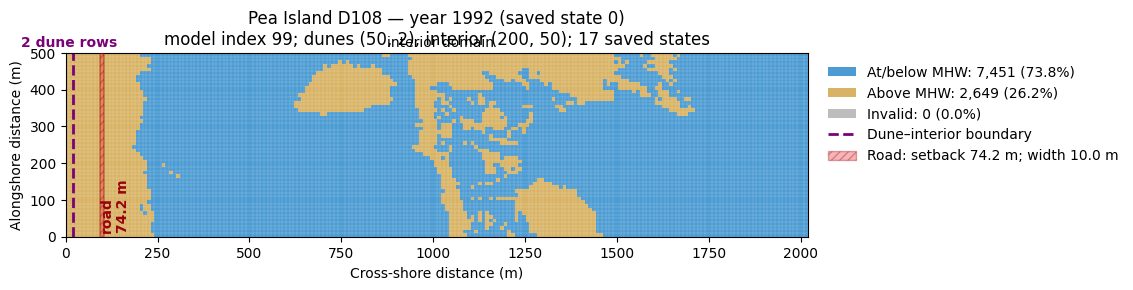

Interior elevation relative to MHW: -3.00 to 2.65 m
Dune elevation relative to MHW: 1.24 to 1.30 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 74.16 m (_road_setback_TS[0]); width: 10.00 m


{'domain_id': 108,
 'model_index': 99,
 'time_index': 0,
 'combined_shape': (202, 50),
 'dune_shape': (50, 2),
 'interior_shape': (200, 50),
 'berm_elevation_m': 1.14,
 'at_or_below_mhw': 7451,
 'above_mhw': 2649,
 'invalid': 0,
 'road_setback_m': 74.163,
 'road_width_m': 10.0}

In [12]:
summary = plot_domain(domain_id=108, time_index=0, pixel_grid=True)
summary

## Option 2: browse with controls

Use the domain dropdown to move from D80 to D119. The time slider starts at the initial state.

In [13]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    max_time_index = min(
        get_matching_state_count(models[domain_to_model_index(d)]) - 1
        for d in range(FIRST_REAL_DOMAIN, LAST_REAL_DOMAIN + 1)
    )
    domain_control = widgets.Dropdown(
        options=[(f"D{d}", d) for d in range(FIRST_REAL_DOMAIN, LAST_REAL_DOMAIN + 1)],
        value=DEFAULT_DOMAIN,
        description="Domain:",
    )
    time_control = widgets.IntSlider(
        value=TIME_INDEX, min=0, max=max_time_index, step=1,
        description="Time index:", continuous_update=False,
    )
    grid_control = widgets.Checkbox(value=SHOW_PIXEL_GRID, description="Pixel grid")
    output = widgets.interactive_output(
        plot_domain,
        {"domain_id": domain_control, "time_index": time_control, "pixel_grid": grid_control},
    )
    display(widgets.HBox([domain_control, time_control, grid_control]), output)
except ImportError:
    print("ipywidgets is not installed in this kernel. Use the manual plot_domain cell above.")

Output()

## Optional: compare a short list

Add or remove domain numbers, then run this cell. Keeping the list short makes the notebook easier to browse.

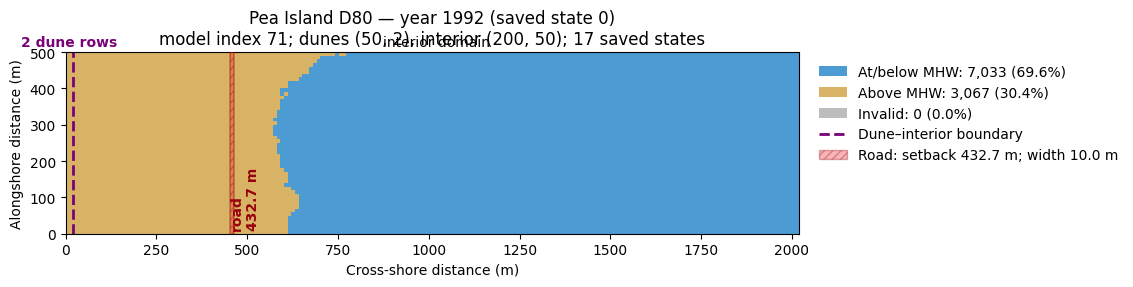

Interior elevation relative to MHW: -3.00 to 1.91 m
Dune elevation relative to MHW: 1.24 to 1.45 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 432.70 m (_road_setback_TS[0]); width: 10.00 m


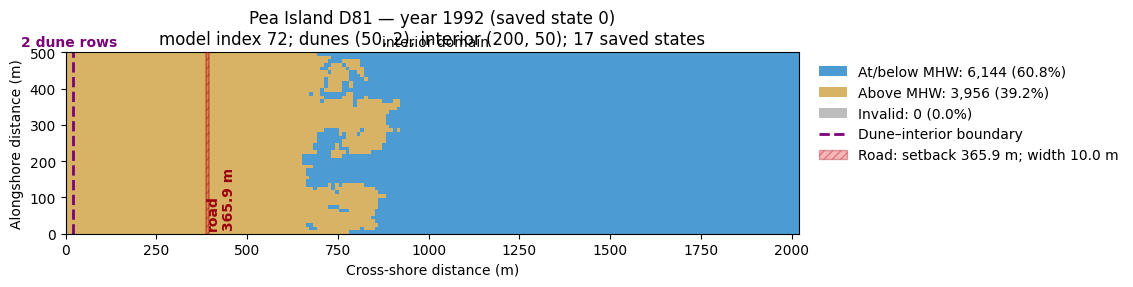

Interior elevation relative to MHW: -3.00 to 4.83 m
Dune elevation relative to MHW: 1.24 to 2.66 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 365.90 m (_road_setback_TS[0]); width: 10.00 m


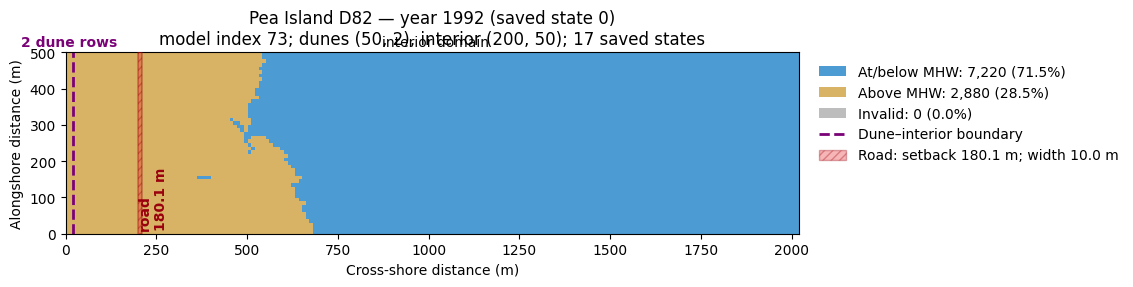

Interior elevation relative to MHW: -3.00 to 2.82 m
Dune elevation relative to MHW: 1.24 to 2.53 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 180.07 m (_road_setback_TS[0]); width: 10.00 m


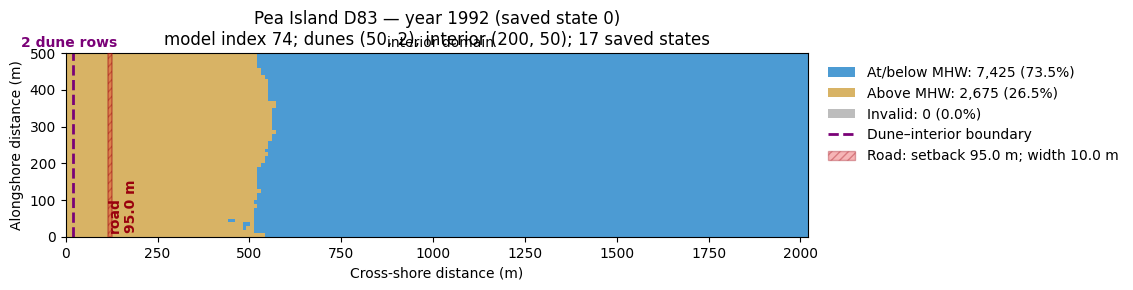

Interior elevation relative to MHW: -3.00 to 3.63 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 95.00 m (_road_setback_TS[0]); width: 10.00 m


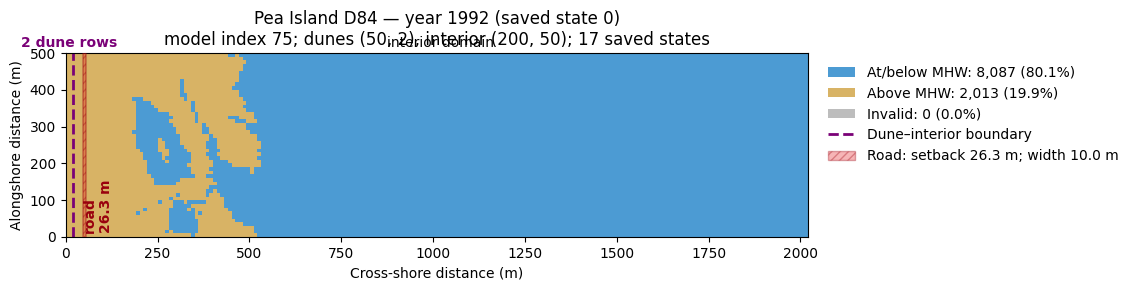

Interior elevation relative to MHW: -3.00 to 2.52 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 26.30 m (_road_setback_TS[0]); width: 10.00 m


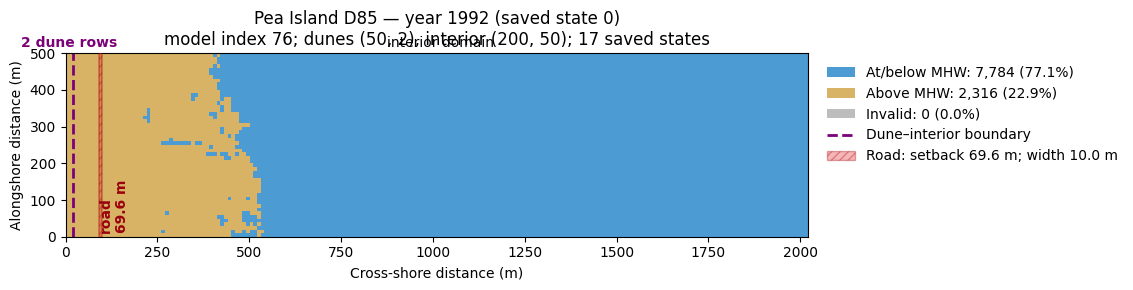

Interior elevation relative to MHW: -3.00 to 1.73 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 69.60 m (_road_setback_TS[0]); width: 10.00 m


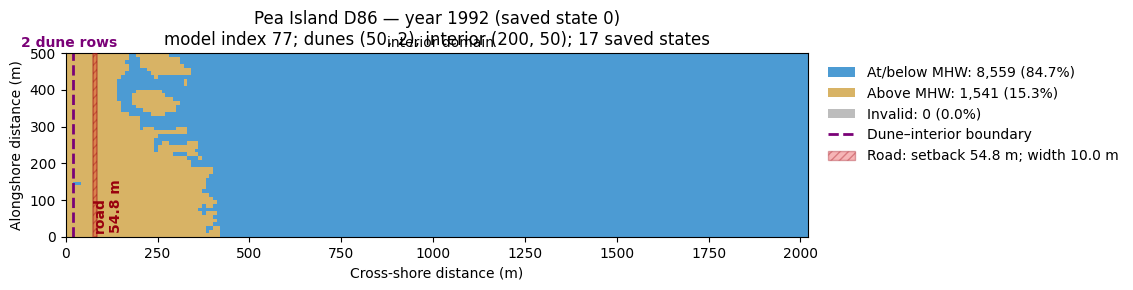

Interior elevation relative to MHW: -3.00 to 1.73 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 54.80 m (_road_setback_TS[0]); width: 10.00 m


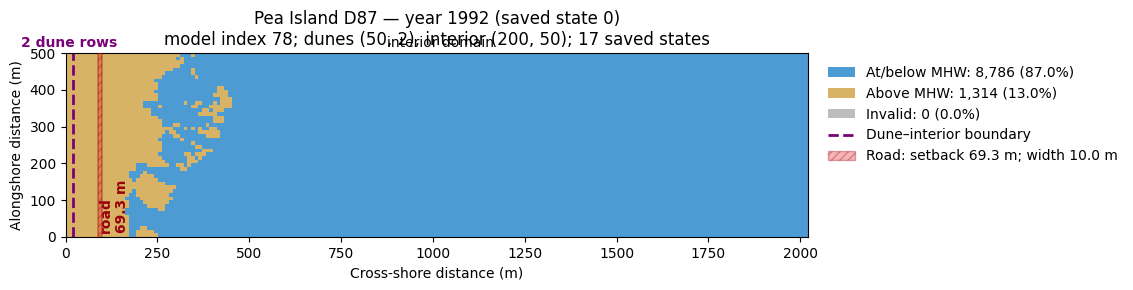

Interior elevation relative to MHW: -3.00 to 2.09 m
Dune elevation relative to MHW: 1.24 to 1.67 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 69.30 m (_road_setback_TS[0]); width: 10.00 m


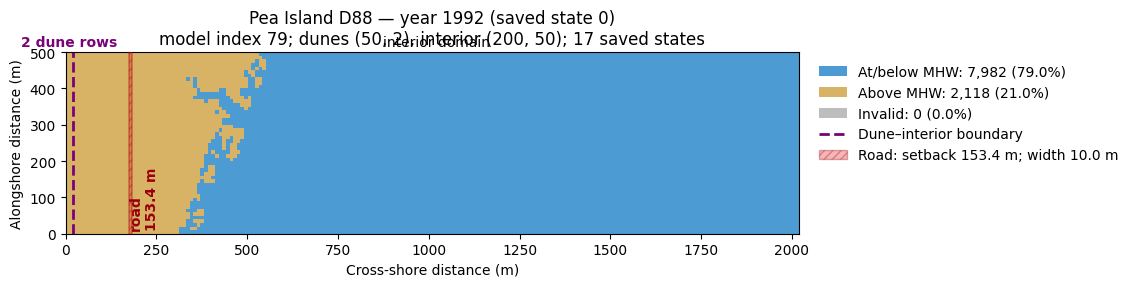

Interior elevation relative to MHW: -3.00 to 3.16 m
Dune elevation relative to MHW: 1.24 to 2.08 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 153.40 m (_road_setback_TS[0]); width: 10.00 m


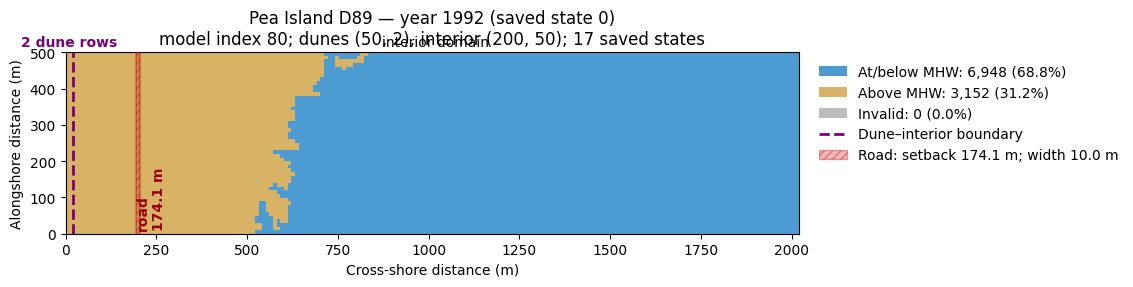

Interior elevation relative to MHW: -3.00 to 1.95 m
Dune elevation relative to MHW: 1.24 to 2.16 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 174.05 m (_road_setback_TS[0]); width: 10.00 m


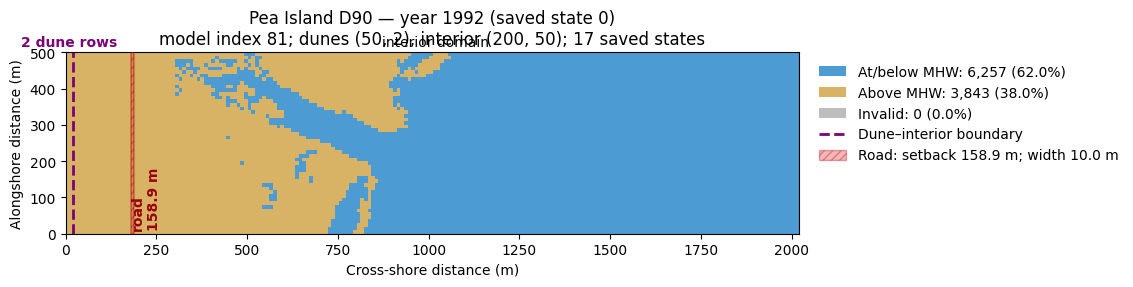

Interior elevation relative to MHW: -3.00 to 2.05 m
Dune elevation relative to MHW: 1.24 to 2.29 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 158.91 m (_road_setback_TS[0]); width: 10.00 m


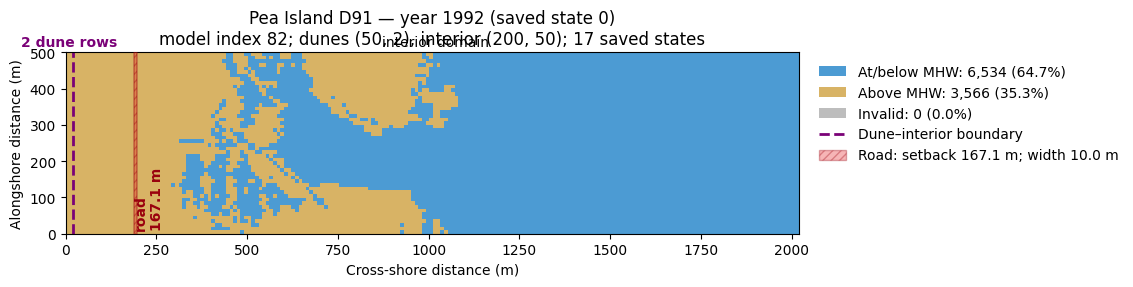

Interior elevation relative to MHW: -3.00 to 2.21 m
Dune elevation relative to MHW: 1.24 to 2.33 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 167.12 m (_road_setback_TS[0]); width: 10.00 m


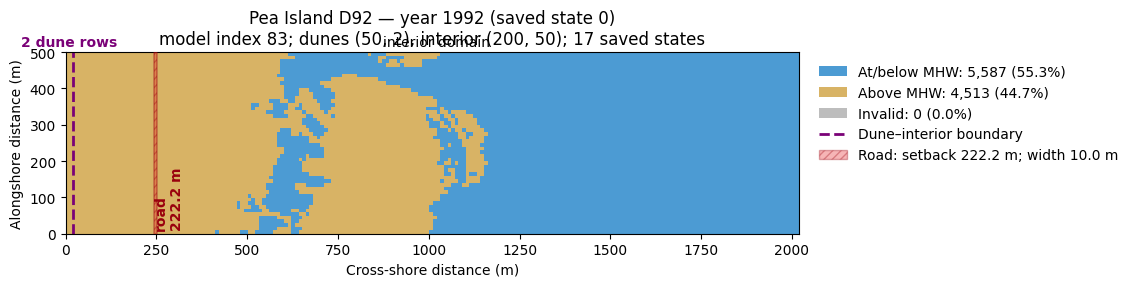

Interior elevation relative to MHW: -3.00 to 1.97 m
Dune elevation relative to MHW: 1.24 to 2.16 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 222.21 m (_road_setback_TS[0]); width: 10.00 m


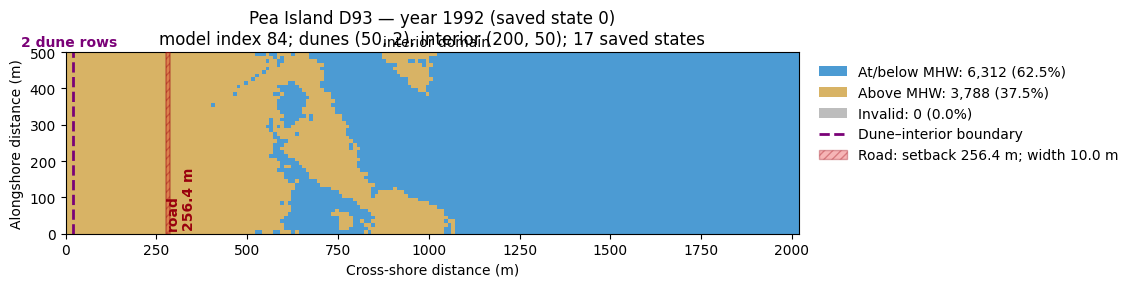

Interior elevation relative to MHW: -3.00 to 1.94 m
Dune elevation relative to MHW: 1.24 to 2.09 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 256.40 m (_road_setback_TS[0]); width: 10.00 m


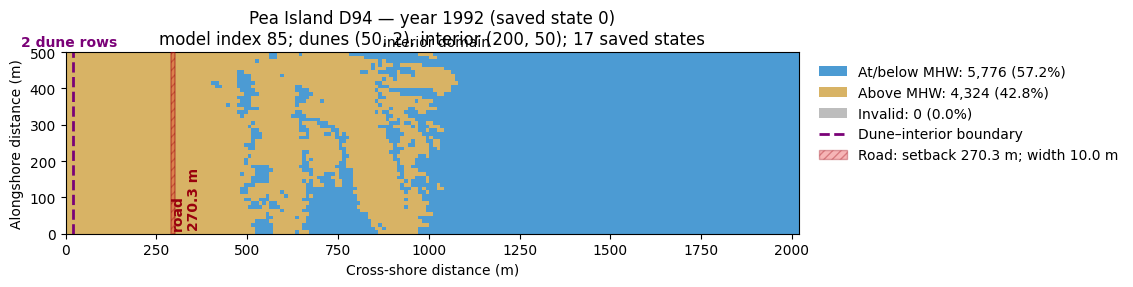

Interior elevation relative to MHW: -3.00 to 3.84 m
Dune elevation relative to MHW: 1.24 to 2.01 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 270.26 m (_road_setback_TS[0]); width: 10.00 m


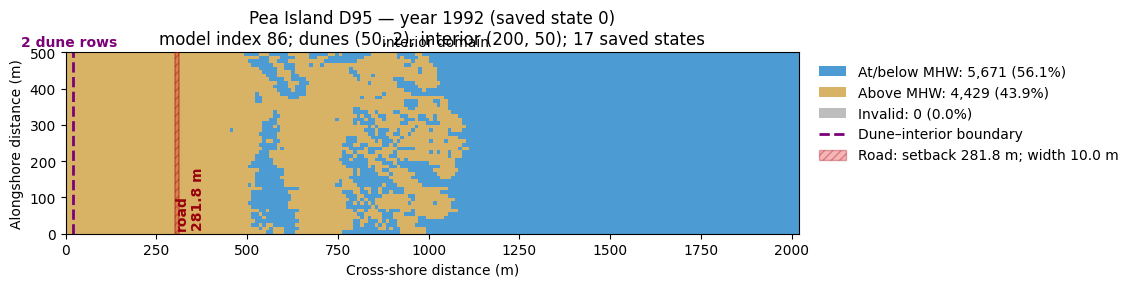

Interior elevation relative to MHW: -3.00 to 2.65 m
Dune elevation relative to MHW: 1.24 to 1.53 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 281.78 m (_road_setback_TS[0]); width: 10.00 m


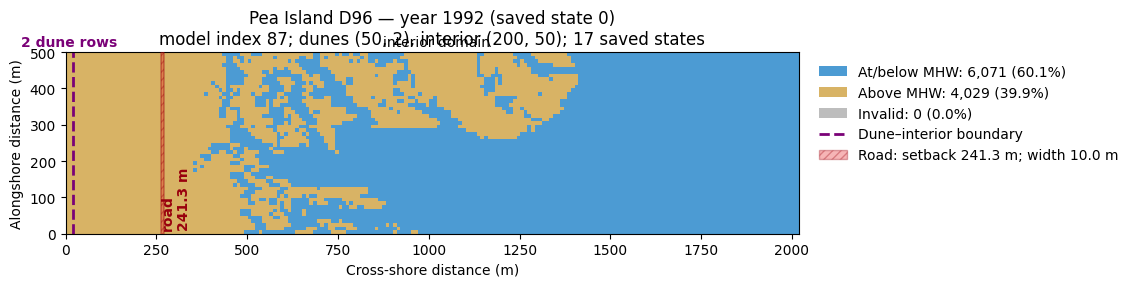

Interior elevation relative to MHW: -3.00 to 2.25 m
Dune elevation relative to MHW: 1.24 to 1.69 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 241.32 m (_road_setback_TS[0]); width: 10.00 m


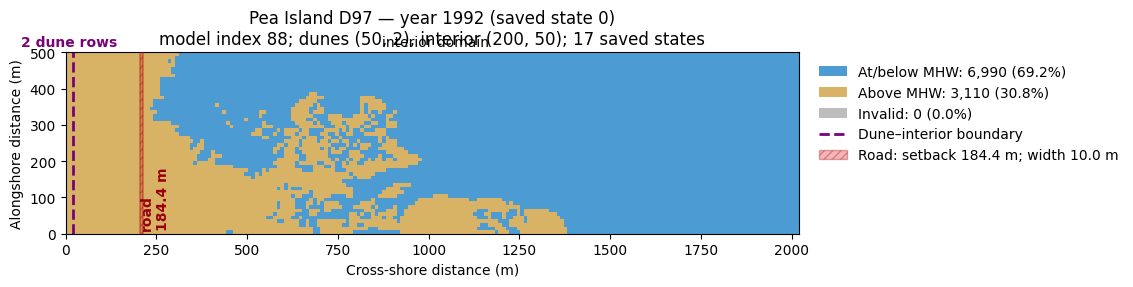

Interior elevation relative to MHW: -3.00 to 2.01 m
Dune elevation relative to MHW: 1.24 to 2.11 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 184.38 m (_road_setback_TS[0]); width: 10.00 m


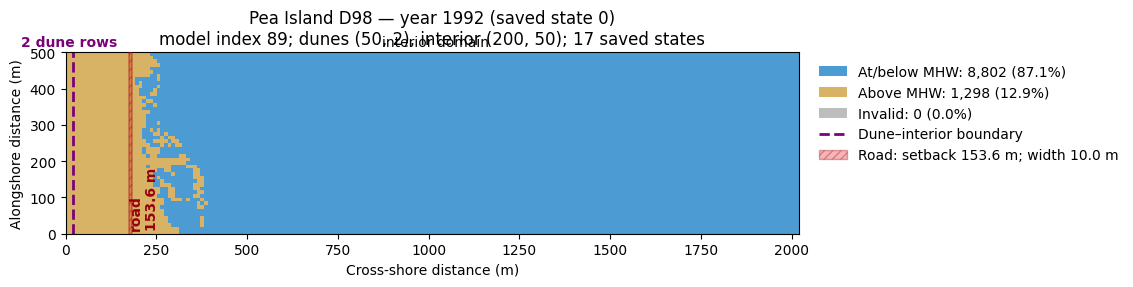

Interior elevation relative to MHW: -3.00 to 1.68 m
Dune elevation relative to MHW: 1.24 to 1.89 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 153.60 m (_road_setback_TS[0]); width: 10.00 m


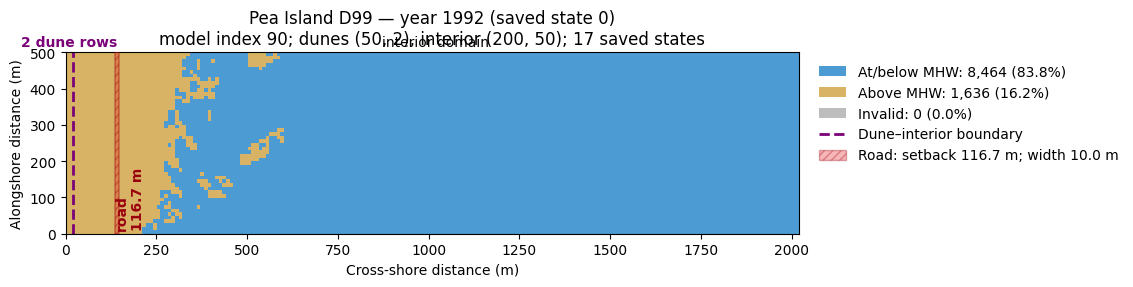

Interior elevation relative to MHW: -3.00 to 1.74 m
Dune elevation relative to MHW: 1.24 to 1.55 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 116.68 m (_road_setback_TS[0]); width: 10.00 m


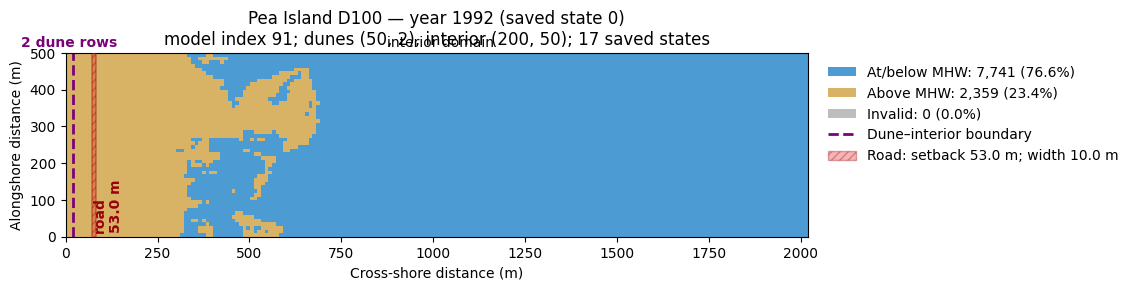

Interior elevation relative to MHW: -3.00 to 3.82 m
Dune elevation relative to MHW: 1.24 to 1.64 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 53.04 m (_road_setback_TS[0]); width: 10.00 m


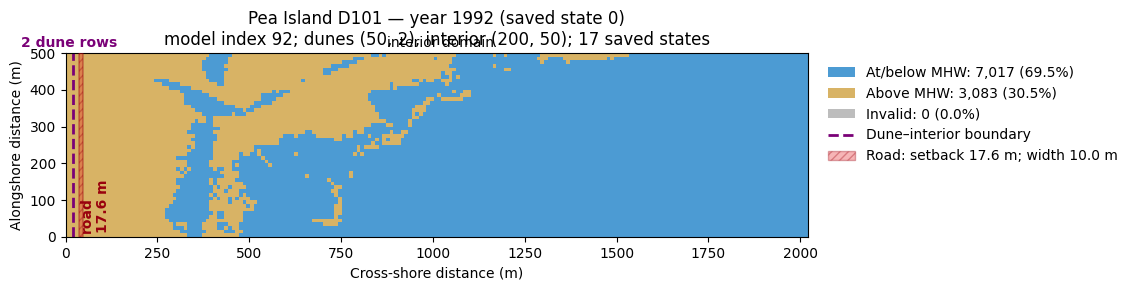

Interior elevation relative to MHW: -3.00 to 6.14 m
Dune elevation relative to MHW: 1.24 to 1.39 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 17.59 m (_road_setback_TS[0]); width: 10.00 m


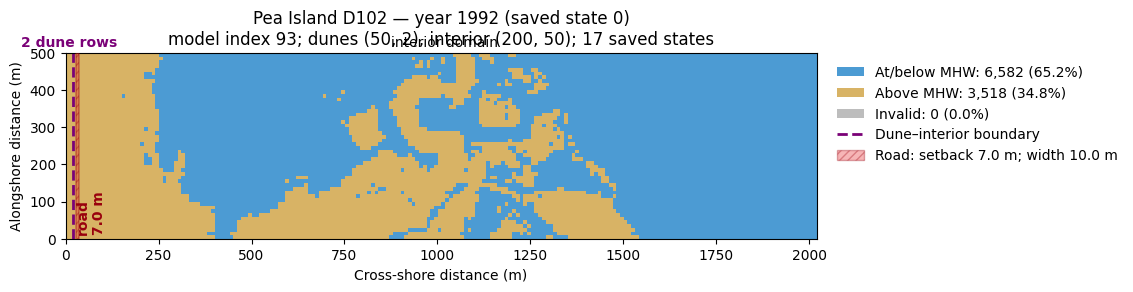

Interior elevation relative to MHW: -3.00 to 8.10 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 6.96 m (_road_setback_TS[0]); width: 10.00 m


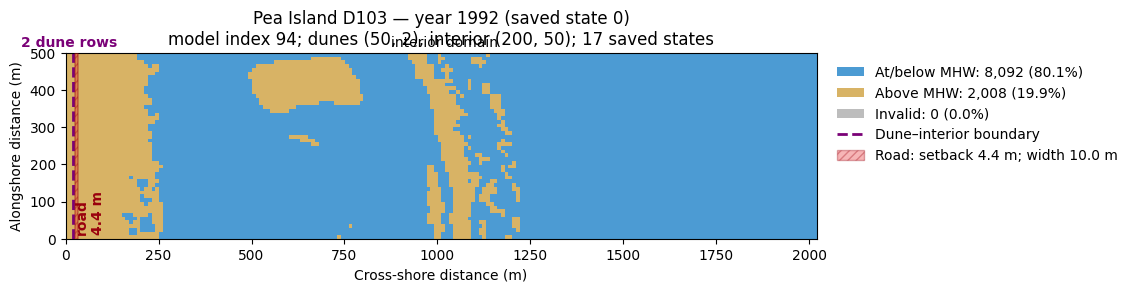

Interior elevation relative to MHW: -3.00 to 7.34 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 4.36 m (_road_setback_TS[0]); width: 10.00 m


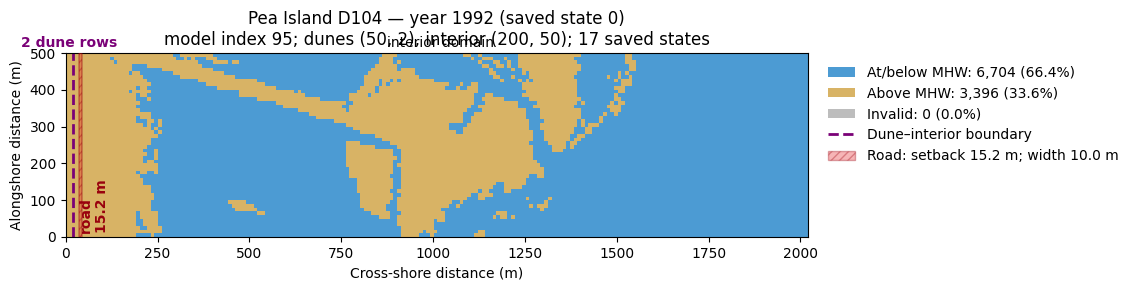

Interior elevation relative to MHW: -3.00 to 7.59 m
Dune elevation relative to MHW: 1.24 to 2.61 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 15.15 m (_road_setback_TS[0]); width: 10.00 m


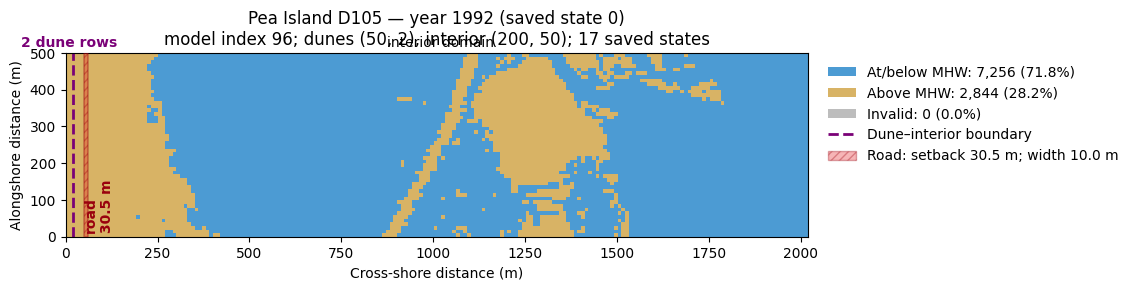

Interior elevation relative to MHW: -3.00 to 6.64 m
Dune elevation relative to MHW: 1.24 to 2.92 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 30.47 m (_road_setback_TS[0]); width: 10.00 m


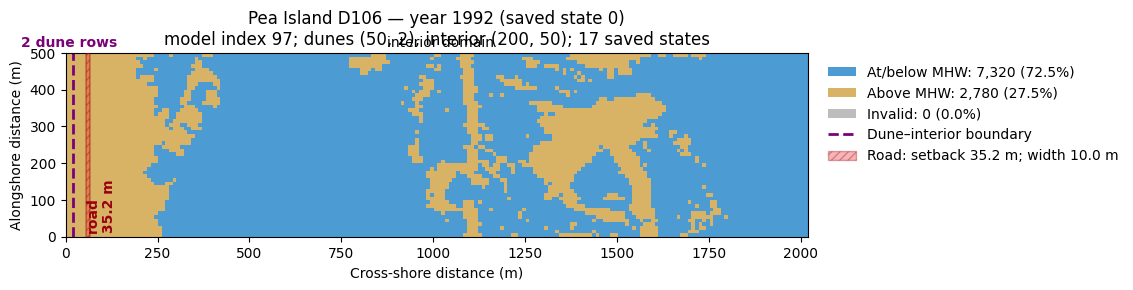

Interior elevation relative to MHW: -3.00 to 6.48 m
Dune elevation relative to MHW: 1.24 to 2.09 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 35.17 m (_road_setback_TS[0]); width: 10.00 m


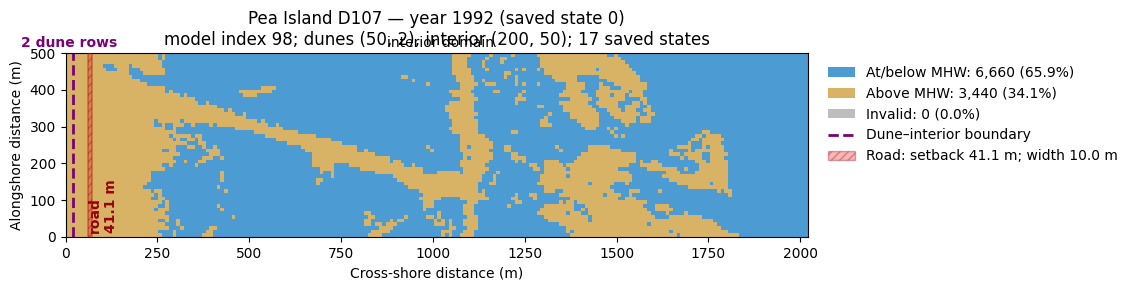

Interior elevation relative to MHW: -3.00 to 6.72 m
Dune elevation relative to MHW: 1.24 to 1.74 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 41.09 m (_road_setback_TS[0]); width: 10.00 m


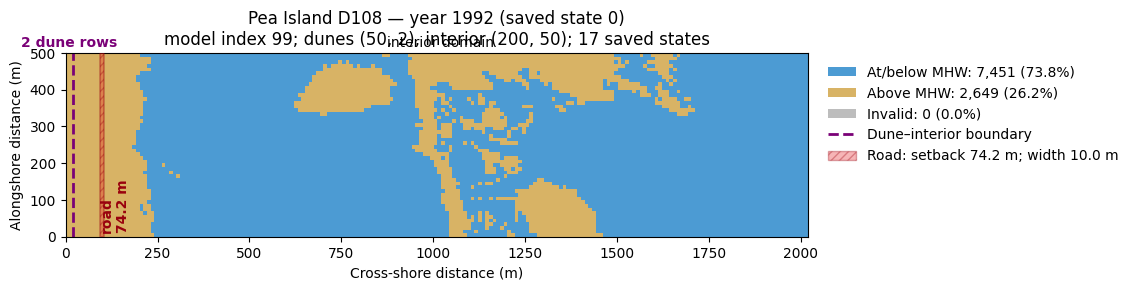

Interior elevation relative to MHW: -3.00 to 2.65 m
Dune elevation relative to MHW: 1.24 to 1.30 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 74.16 m (_road_setback_TS[0]); width: 10.00 m


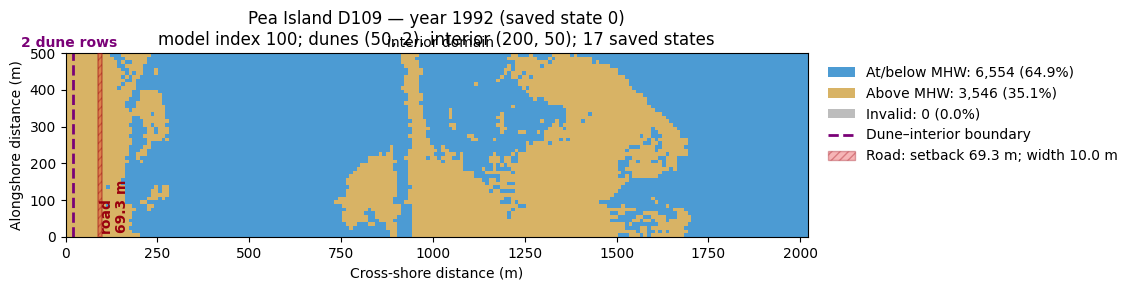

Interior elevation relative to MHW: -3.00 to 3.36 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 69.35 m (_road_setback_TS[0]); width: 10.00 m


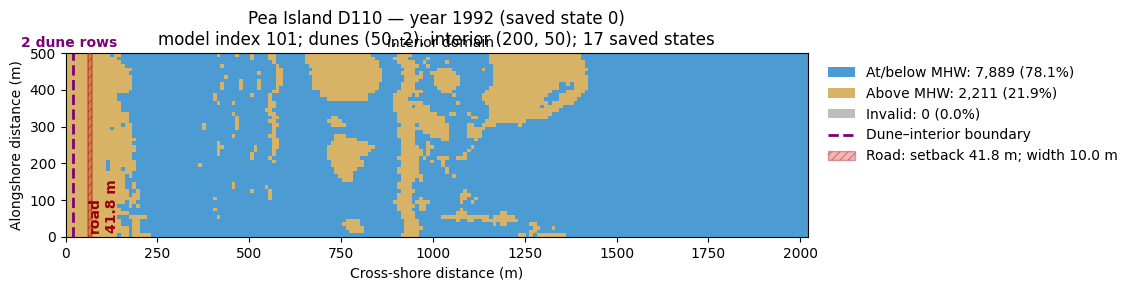

Interior elevation relative to MHW: -3.00 to 3.28 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 41.84 m (_road_setback_TS[0]); width: 10.00 m


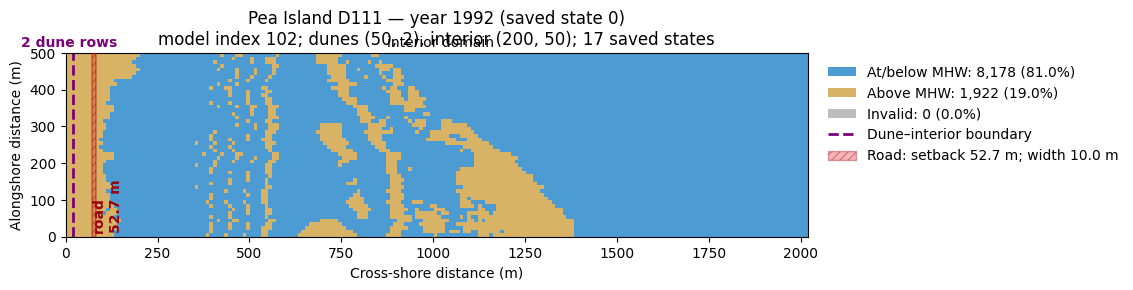

Interior elevation relative to MHW: -3.00 to 2.65 m
Dune elevation relative to MHW: 1.24 to 1.24 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 52.69 m (_road_setback_TS[0]); width: 10.00 m


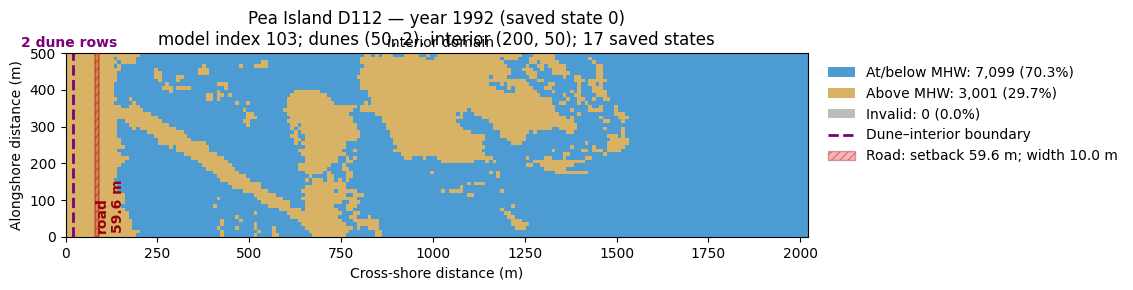

Interior elevation relative to MHW: -3.00 to 3.54 m
Dune elevation relative to MHW: 1.24 to 1.33 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 59.64 m (_road_setback_TS[0]); width: 10.00 m


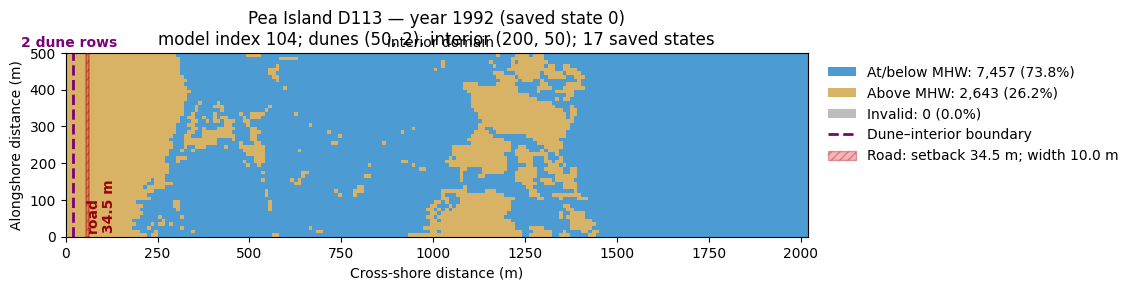

Interior elevation relative to MHW: -3.00 to 2.50 m
Dune elevation relative to MHW: 1.24 to 1.42 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 34.55 m (_road_setback_TS[0]); width: 10.00 m


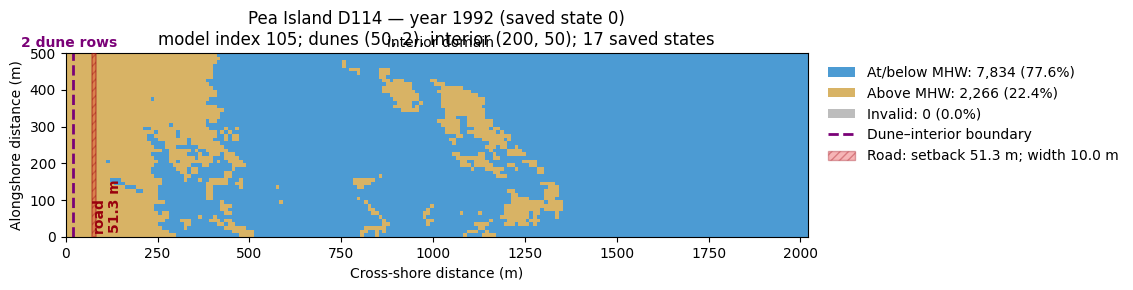

Interior elevation relative to MHW: -3.00 to 2.63 m
Dune elevation relative to MHW: 1.24 to 2.84 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 51.35 m (_road_setback_TS[0]); width: 10.00 m


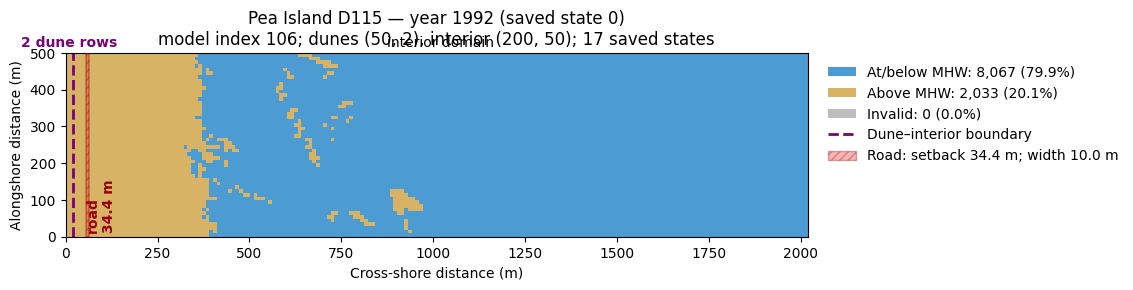

Interior elevation relative to MHW: -3.00 to 3.12 m
Dune elevation relative to MHW: 1.24 to 2.11 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 34.40 m (_road_setback_TS[0]); width: 10.00 m


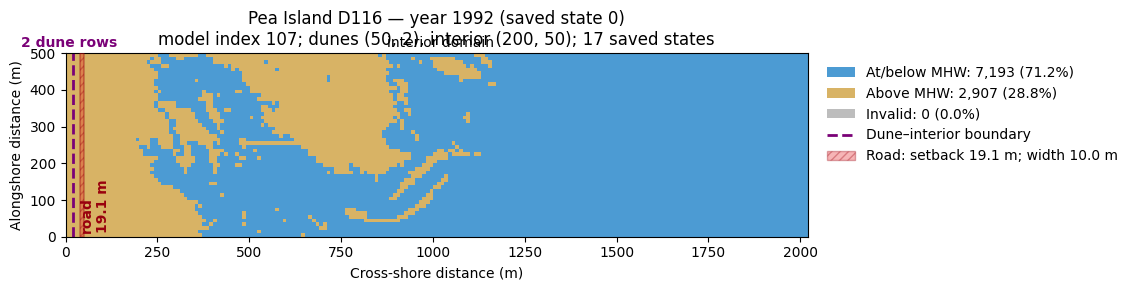

Interior elevation relative to MHW: -3.00 to 4.66 m
Dune elevation relative to MHW: 1.24 to 2.08 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 19.08 m (_road_setback_TS[0]); width: 10.00 m


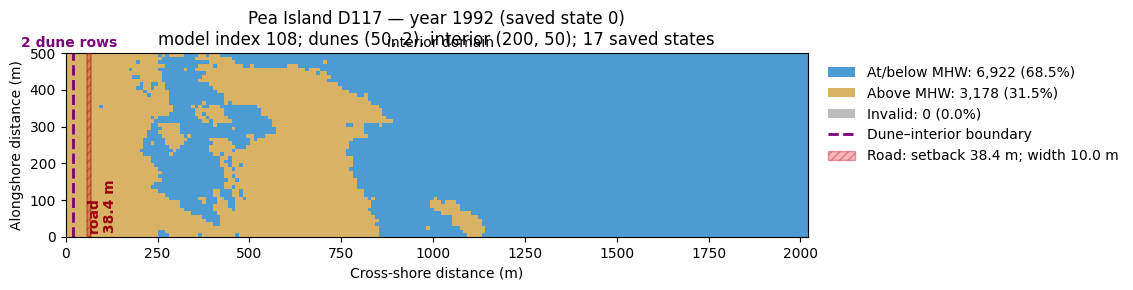

Interior elevation relative to MHW: -3.00 to 3.73 m
Dune elevation relative to MHW: 1.24 to 2.56 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 38.40 m (_road_setback_TS[0]); width: 10.00 m


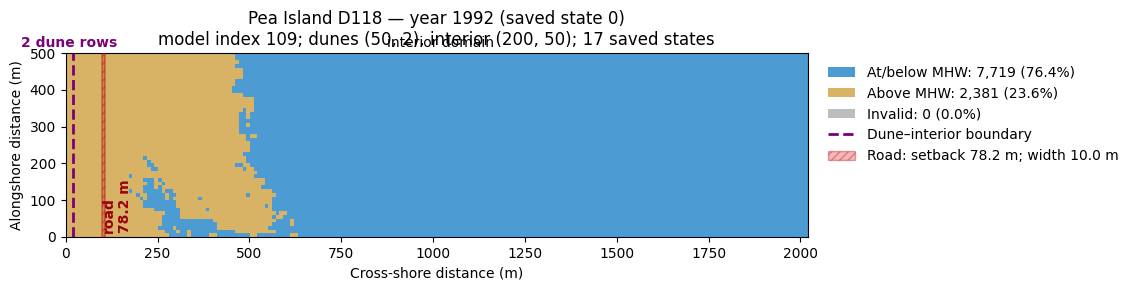

Interior elevation relative to MHW: -3.00 to 4.15 m
Dune elevation relative to MHW: 1.24 to 1.94 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 78.23 m (_road_setback_TS[0]); width: 10.00 m


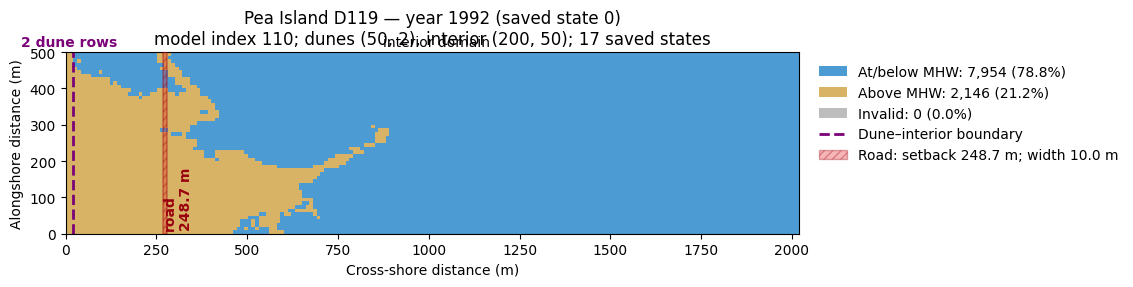

Interior elevation relative to MHW: -3.00 to 4.48 m
Dune elevation relative to MHW: 1.24 to 2.84 m; berm=1.14 m (BermEl)
Road setback from dune/interior edge: 248.72 m (_road_setback_TS[0]); width: 10.00 m


In [14]:
DOMAINS_TO_SHOW = list(range(80, 120))

for domain_id in DOMAINS_TO_SHOW:
    plot_domain(domain_id=domain_id, time_index=0, pixel_grid=False)

### Assumptions used by this notebook

1. `DomainTS` elevations are stored in **decameters relative to MHW**, so the MHW threshold is `0.0` in the raw array.
2. The dune history is read from `DuneDomain[time]` for this Barrier3D version, with `DuneDomainTS[time]` also supported. These values are dune heights above the berm. The notebook adds the domain's saved `BermEl` to classify dune cells relative to MHW; 1.5 m is only a fallback if `BermEl` is unavailable.
3. Saved states `DomainTS[0]` and `DuneDomain[0]` are the initial 1992 state.
4. For a padded 111-domain run, there are 71 left buffer domains: D80 → index 71, D108 → index 99, and D119 → index 110. A 40-domain real-only result is also detected automatically.
5. Each pixel is 10 m × 10 m.
6. The dune rows are placed at the ocean side (left), followed by the interior domain. Road pixels are not overlaid.
7. The arrays are oriented for display but not flipped.
8. The road setback and width come from `_road_setback_TS[time_index]` and `_road_width_TS[time_index]`. Setback is measured landward from the dune/interior boundary, so the plotted road begins at `dune_width + setback`. Domains without a saved RoadwayManager are left without a road overlay.